In [1]:
print("hello world")

hello world


In [2]:
!pip install torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 6.6 MB/s eta 0:00:00m eta 0:00:010:01:010m


Training samples: 10000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Label: 7


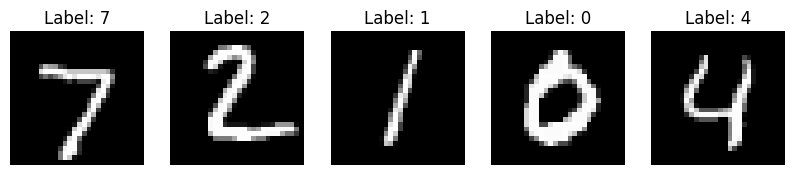

In [5]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()


train_dataset = datasets.MNIST(
    root = "./data",
    train = True,
    download = True,
    transform = transform
)

train_dataset = datasets.MNIST(
    root = "./data",
    train = False,
    download = True,
    transform = transform
)


print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)


fig, axes = plt.subplots(1, 5, figsize=(10, 3))


for i in range(5):
    image, label = train_dataset[i]
    
    axes[i].imshow(image.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.show()

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

# Get one batch
images, labels = next(iter(train_loader))

# Print shapes
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

# Print first few labels
print(labels[:10])

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
tensor([8, 7, 2, 0, 7, 5, 7, 3, 1, 7])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F




class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2)

        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

  
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)

        return x


model = Net()
print(model)


dummy = torch.randn(64, 1, 28, 28)

output = model(dummy)

print(output.shape)


total_params = sum(p.numel() for p in model.parameters())

print(total_params)

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
torch.Size([64, 10])
421642
